# 2026-06-24 Initial Check: rMZR Binned by Global Gas Properties

This notebook reproduces only the analyses corresponding to **one-based cells 17 and 22** of
`20260618_initial_check_rMZR_binned_by_EWHa.ipynb`.

Both analyses are repeated with galaxy-level colors from
`mauve_master_wiki_newclass.fits`:

1. total H I mass (`logMHI`);
2. total H$_2$ mass (`logMH2`);
3. total $M_{\rm HI}/M_{\rm H2}$;
4. total $M_{\rm HI}/(M_{\rm HI}+M_{\rm H2})$;
5. total $M_{\rm H2}/(M_{\rm HI}+M_{\rm H2})$.

The three ratios are calculated after converting `logMHI` and `logMH2` to linear masses.
Each galaxy therefore has one color value, shared by all of its plotted spaxels or trend
segments. NGC4383 remains excluded, matching the source analyses. Figure-saving calls are
intentionally omitted.

## Setup and live product discovery

In [1]:

# Further-project initial checks for the v3tk v7.6.8 products.
# This notebook was adapted from the previous flat `extended` project layout.
# It now discovers products under `v3tk_v7.6.8/<galaxy>/` from the current cwd.

from __future__ import annotations

import math
import re
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
REFERENCE_ROOT = (PROJECT_ROOT.parent / "extended").resolve()
OUTDIR = PROJECT_ROOT / "quicklook_figures"

KEY_LINES = [
    "HB4861",
    "OIII5006",
    "HA6562",
    "NII6583",
    "SII6716",
    "SII6730",
    "SIII6312",
    "OII7318",
    "OII7319",
    "OII7329",
    "OII7330",
]

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Run directory: {RUN_DIR}")
if REFERENCE_ROOT.exists() and str(REFERENCE_ROOT) not in sys.path:
    sys.path.append(str(REFERENCE_ROOT))

print(f"Reference resources fallback: {REFERENCE_ROOT}")
print(f"Active save paths are intentionally commented out in this notebook.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Reference resources fallback: /Users/Igniz/Desktop/ICRAR/extended
Active save paths are intentionally commented out in this notebook.


In [2]:

def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not path.exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(p for p in run_dir.iterdir() if p.is_dir()):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        spatial_extended = gal_dir / f"{gal}_spatial_binning_maps_extended.fits"
        gas_raw = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_further = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_extended = gal_dir / f"{gal}_gas_BIN_maps_extended.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_extended, spatial_raw)
        gas_preferred = first_existing(gas_further, gas_extended, gas_raw)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [
        fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"])
        for path in table["spatial_path"]
    ]
    table["has_sfr_map"] = [
        fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"])
        for path in table["gas_path"]
    ]
    table["has_o3n2_m13"] = [
        fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"])
        for path in table["gas_path"]
    ]
    table["has_proxy_ew"] = [
        first_existing(
            Path(row["folder"]) / f"{gal}_proxy_EW_maps_further.fits",
            Path(row["folder"]) / f"{gal}_proxy_EW_maps.fits",
            PROJECT_ROOT / f"{gal}_proxy_EW_maps_further.fits",
            PROJECT_ROOT / f"{gal}_proxy_EW_maps.fits",
        ) is not None
        for gal, row in table.iterrows()
    ]
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table


PRODUCTS = discover_further_products()


def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps_further.fits", "_proxy_EW_maps.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    folder = PRODUCTS.loc[galaxy, "folder"] if galaxy in PRODUCTS.index else RUN_DIR / galaxy
    for suffix_item in dict.fromkeys(suffixes):
        candidates.extend([
            Path(folder) / f"{galaxy}{suffix_item}",
            PROJECT_ROOT / f"{galaxy}{suffix_item}",
        ])
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0

RAW_GAS_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
READY_PHYSICS_GALAXIES = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()

summary_columns = [
    "has_spatial",
    "has_gas",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "ready_raw_gas_qc",
    "ready_sfh_qc",
    "ready_physics_maps",
]

print(f"Discovered {len(PRODUCTS)} galaxy folders in {RUN_LABEL}.")
print(f"Raw gas QC-ready galaxies: {len(RAW_GAS_GALAXIES)}")
print(f"SFH QC-ready galaxies: {len(SFH_GALAXIES)}")
print(f"Previous-paper physics-map ready galaxies: {len(READY_PHYSICS_GALAXIES)}")
display(PRODUCTS[summary_columns])


Discovered 29 galaxy folders in v3tk_v7.6.8.
Raw gas QC-ready galaxies: 29
SFH QC-ready galaxies: 29
Previous-paper physics-map ready galaxies: 29


,has_spatial,has_gas,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,ready_raw_gas_qc,ready_sfh_qc,ready_physics_maps
galaxy,,,,,,,,,,,,,,
IC3392,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4064,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4189,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4192,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4254,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4293,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4294,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4298,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4302,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [3]:
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
from scipy import ndimage, stats

MASTER_GAS_TABLE = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
EXCLUDED_GALAXIES = {"NGC4383"}
EW_FILE_SUFFIX = "_proxy_EW_maps.fits"
EW_HDU = "PROXY_EWHA"
EW_MIN = 6.0
COMMON_YLIM = (8.2, 8.9)
XRANGE_RMZR = (6.0, 10.0)
XRANGE_ZGAS = (-5.0, 0.5)


def decode_galaxy_name(value) -> str:
    if isinstance(value, (bytes, np.bytes_)):
        value = value.decode("utf-8")
    return str(value).strip()


def load_global_gas_properties(path=MASTER_GAS_TABLE) -> pd.DataFrame:
    """Read log gas masses and derive linear mass ratios for each galaxy."""
    with fits.open(path, memmap=True) as hdul:
        table_hdu = next(hdu for hdu in hdul if isinstance(hdu, fits.BinTableHDU))
        required = {"Galaxy", "logMHI", "logMH2"}
        missing = required.difference(table_hdu.columns.names)
        if missing:
            raise KeyError(f"{path} is missing required columns: {sorted(missing)}")
        galaxy = [decode_galaxy_name(value) for value in table_hdu.data["Galaxy"]]
        log_mhi = np.asarray(table_hdu.data["logMHI"], dtype=float)
        log_mh2 = np.asarray(table_hdu.data["logMH2"], dtype=float)

    mhi = np.power(10.0, log_mhi)
    mh2 = np.power(10.0, log_mh2)
    total = mhi + mh2

    gas = pd.DataFrame(
        {
            "galaxy": galaxy,
            "logMHI": log_mhi,
            "logMH2": log_mh2,
            "MHI_over_MH2": np.divide(
                mhi, mh2, out=np.full_like(mhi, np.nan), where=mh2 > 0
            ),
            "f_HI": np.divide(
                mhi, total, out=np.full_like(mhi, np.nan), where=total > 0
            ),
            "f_H2": np.divide(
                mh2, total, out=np.full_like(mh2, np.nan), where=total > 0
            ),
        }
    ).set_index("galaxy")

    if gas.index.has_duplicates:
        duplicates = gas.index[gas.index.duplicated()].unique().tolist()
        raise ValueError(f"Duplicate galaxy rows in {path}: {duplicates}")

    # The science products use one combined NGC4567_8 cube, while the master
    # table lists NGC4567 and NGC4568 separately. Sum both components in linear
    # mass space before deriving the combined logarithmic masses and fractions.
    combined_id = "NGC4567_8"
    components = ["NGC4567", "NGC4568"]
    if combined_id not in gas.index and all(galaxy in gas.index for galaxy in components):
        combined_mhi = sum(10.0 ** gas.at[galaxy, "logMHI"] for galaxy in components)
        combined_mh2 = sum(10.0 ** gas.at[galaxy, "logMH2"] for galaxy in components)
        combined_total = combined_mhi + combined_mh2
        gas.loc[combined_id] = {
            "logMHI": np.log10(combined_mhi),
            "logMH2": np.log10(combined_mh2),
            "MHI_over_MH2": combined_mhi / combined_mh2,
            "f_HI": combined_mhi / combined_total,
            "f_H2": combined_mh2 / combined_total,
        }
    return gas


GAS_PROPERTIES = load_global_gas_properties()

GAS_METRICS = {
    "logMHI": {
        "label": r"$\log(M_{\rm HI}/M_\odot)$",
        "cmap": "viridis",
        "scale": "linear",
    },
    "logMH2": {
        "label": r"$\log(M_{\rm H2}/M_\odot)$",
        "cmap": "viridis",
        "scale": "linear",
    },
    "MHI_over_MH2": {
        "label": r"$M_{\rm HI}/M_{\rm H2}$",
        "cmap": "viridis",
        "scale": "log",
    },
    "f_HI": {
        "label": r"$M_{\rm HI}/(M_{\rm HI}+M_{\rm H2})$",
        "cmap": "viridis",
        "scale": "linear",
    },
    "f_H2": {
        "label": r"$M_{\rm H2}/(M_{\rm HI}+M_{\rm H2})$",
        "cmap": "viridis",
        "scale": "linear",
    },
}


def metric_style(metric_key, galaxies):
    """Return finite galaxy values, colormap, and normalization for one metric."""
    spec = GAS_METRICS[metric_key]
    values = pd.Series(
        {
            gal: GAS_PROPERTIES.at[gal, metric_key]
            for gal in galaxies
            if gal in GAS_PROPERTIES.index
        },
        dtype=float,
    )
    values = values[np.isfinite(values)]
    if values.empty:
        raise ValueError(f"No finite values available for {metric_key}")

    vmin = float(values.min())
    vmax = float(values.max())
    if np.isclose(vmin, vmax):
        delta = max(abs(vmin) * 0.01, 1e-6)
        vmin, vmax = vmin - delta, vmax + delta

    if spec["scale"] == "log":
        positive = values[values > 0]
        if positive.empty:
            raise ValueError(f"{metric_key} has no positive values for logarithmic colors")
        norm = LogNorm(vmin=float(positive.min()), vmax=float(positive.max()))
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    return values, plt.get_cmap(spec["cmap"]), norm, spec["label"]


available_physics = physics_ready_galaxies(require_ew=True)
missing_master_rows = sorted(set(available_physics).difference(GAS_PROPERTIES.index))
print(f"Global gas table: {MASTER_GAS_TABLE}")
print(f"Rows in gas table: {len(GAS_PROPERTIES)}")
print(f"Physics + EW ready galaxies: {len(available_physics)}")
print(f"Ready galaxies missing from gas table: {missing_master_rows or 'none'}")
display(GAS_PROPERTIES.loc[GAS_PROPERTIES.index.intersection(available_physics)])


Global gas table: /Users/Igniz/Desktop/ICRAR/further/mauve_master_wiki_newclass.fits
Rows in gas table: 41
Physics + EW ready galaxies: 29
Ready galaxies missing from gas table: none


,logMHI,logMH2,MHI_over_MH2,f_HI,f_H2
galaxy,,,,,
NGC4189,8.780265,8.552060,1.691240,0.628424,0.371576
NGC4192,9.655333,9.122061,3.414066,0.773451,0.226549
NGC4254,9.672950,9.742061,0.852884,0.460301,0.539699
NGC4294,9.239791,7.612060,42.435619,0.976977,0.023023
NGC4351,8.502618,7.712060,6.173877,0.860605,0.139395
NGC4383,9.491804,8.242060,17.772336,0.946730,0.053270
NGC4396,8.962783,7.922060,10.983054,0.916549,0.083451
NGC4298,8.721483,8.952061,0.588061,0.370301,0.629699
NGC4302,9.198075,8.962060,1.721928,0.632613,0.367387


## Shared science helpers

In [4]:
def load_hii_maps(galaxy, *, prefer_m14=False, include_ew=True):
    """Load aligned HII-region maps with the source notebook's EW and sigma masks."""
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)

    with fits.open(spatial_path, memmap=True) as h_spatial:
        log_sigma_m = np.asarray(
            h_spatial["LOGMASS_SURFACE_DENSITY"].data, dtype=float
        )

    with fits.open(gas_path, memmap=True) as h_gas:
        log_sigma_sfr = np.asarray(
            h_gas["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float
        )
        sigma_obs = np.asarray(h_gas["HA6562_SIGMA"].data, dtype=float)
        if "HA6562_SIGMA_CORR" not in h_gas:
            raise KeyError(f"{galaxy}: missing HA6562_SIGMA_CORR in {gas_path}")
        sigma_corr = np.asarray(h_gas["HA6562_SIGMA_CORR"].data, dtype=float)
        sigma_corr = align_map_to_shape(
            sigma_corr, sigma_obs.shape, label=f"{galaxy} HA6562_SIGMA_CORR"
        )
        sigma2 = sigma_obs**2 - sigma_corr**2
        sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
        sigma_ok = np.isfinite(sigma2) & (sigma2 > 0)
        sigma_intrinsic[sigma_ok] = np.sqrt(sigma2[sigma_ok])

        if prefer_m14 and "O_H_O3N2_M14_HII" in h_gas:
            metallicity = np.asarray(h_gas["O_H_O3N2_M14_HII"].data, dtype=float)
            indicator = "O3N2-M14"
        elif "O_H_O3N2_M13_HII" in h_gas:
            metallicity = np.asarray(h_gas["O_H_O3N2_M13_HII"].data, dtype=float)
            indicator = "O3N2-M13"
        else:
            raise KeyError(f"{galaxy}: no O3N2-M13 HII metallicity map in {gas_path}")

    ew_ha = None
    if include_ew:
        ew_path = further_ew_path(galaxy, EW_FILE_SUFFIX)
        with fits.open(ew_path, memmap=True) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f"{galaxy}: missing {EW_HDU} in {ew_path}")
            ew_ha = np.asarray(h_ew[EW_HDU].data, dtype=float)
        ew_ha = align_map_to_shape(
            ew_ha, log_sigma_sfr.shape, label=f"{galaxy} {EW_HDU}"
        )

    log_sigma_m = align_map_to_shape(
        log_sigma_m, log_sigma_sfr.shape, label=f"{galaxy} stellar mass"
    )
    metallicity = align_map_to_shape(
        metallicity, log_sigma_sfr.shape, label=f"{galaxy} metallicity"
    )
    sigma_intrinsic = align_map_to_shape(
        sigma_intrinsic, log_sigma_sfr.shape, label=f"{galaxy} intrinsic sigma"
    )

    mask = np.isfinite(sigma_intrinsic) & (sigma_intrinsic < 45.0)
    if ew_ha is not None:
        mask &= np.isfinite(ew_ha) & (ew_ha > EW_MIN)

    log_sigma_sfr = np.where(mask, log_sigma_sfr, np.nan)
    metallicity = np.where(mask, metallicity, np.nan)
    if ew_ha is not None:
        ew_ha = np.where(mask, ew_ha, np.nan)

    return log_sigma_m, log_sigma_sfr, metallicity, indicator, ew_ha


def calculate_binned_stats(x_data, y_data, *, bin_width=0.4, min_unique=20):
    """Median, standard deviation, and count in bins with enough unique y values."""
    x = np.asarray(x_data, dtype=float)
    y = np.asarray(y_data, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    if finite.sum() == 0:
        return tuple(np.array([]) for _ in range(5))

    x = x[finite]
    y = y[finite]
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return tuple(np.array([]) for _ in range(5))

    edges = np.arange(x_min, x_max + bin_width, bin_width)
    if edges.size < 2:
        return tuple(np.array([]) for _ in range(5))
    centers = 0.5 * (edges[:-1] + edges[1:])

    kept_centers, medians, stds, counts, kept_indices = [], [], [], [], []
    for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        in_bin = (x >= left) & (x < right)
        y_bin = y[in_bin]
        if np.unique(y_bin).size >= min_unique:
            kept_centers.append(centers[i])
            medians.append(np.nanmedian(y_bin))
            stds.append(np.nanstd(y_bin))
            counts.append(y_bin.size)
            kept_indices.append(i)

    return (
        np.asarray(kept_centers),
        np.asarray(medians),
        np.asarray(stds),
        np.asarray(counts),
        np.asarray(kept_indices),
    )


def density_mask(
    x_values, y_values, x_range, y_range, *, nbins=100, sigma=2.0,
    return_contour=False
):
    """Select points inside the smoothed 95% density contour."""
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    finite = np.isfinite(x_values) & np.isfinite(y_values)
    empty = np.zeros(x_values.shape, dtype=bool)
    if finite.sum() == 0:
        return (empty, None) if return_contour else empty

    x = x_values[finite]
    y = y_values[finite]
    hist, x_edges, y_edges = np.histogram2d(
        x, y, bins=nbins, range=[x_range, y_range]
    )
    smooth = ndimage.gaussian_filter(hist, sigma=sigma)
    ranked = np.sort(smooth.ravel())[::-1]
    cumulative = np.cumsum(ranked)
    if cumulative.size == 0 or cumulative[-1] <= 0:
        return (empty, None) if return_contour else empty
    level = ranked[np.searchsorted(cumulative, 0.95 * cumulative[-1])]

    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_index = (x - x_range[0]) / dx - 0.5
    y_index = (y - y_range[0]) / dy - 0.5
    local_density = ndimage.map_coordinates(
        smooth, [x_index, y_index], order=1, mode="constant", cval=0.0
    )
    selected = local_density >= level
    full = np.zeros(x_values.shape, dtype=bool)
    full[np.flatnonzero(finite)] = selected

    if not return_contour:
        return full
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    grid_x, grid_y = np.meshgrid(x_centers, y_centers)
    return full, (grid_x, grid_y, smooth.T, level)


def plot_connected_medians(ax, centers, medians, stds, counts, bin_indices, color):
    if centers.size == 0:
        return
    yerr = stds / np.sqrt(counts)
    ax.errorbar(
        centers, medians, yerr=yerr, color=color, marker="o", markersize=4,
        linewidth=1, capsize=3, alpha=0.85
    )
    for i in range(centers.size - 1):
        if bin_indices[i + 1] - bin_indices[i] == 1:
            ax.plot(
                centers[i:i + 2], medians[i:i + 2],
                color=color, linewidth=1.5, alpha=0.85
            )


def sigma_clip_unique(x_values, y_values):
    """Source-cell-style independent 3-sigma clipping from unique x and y values."""
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    keep = np.zeros(x.shape, dtype=bool)
    if finite.sum() == 0:
        return keep
    x_valid = x[finite]
    y_valid = y[finite]
    x_unique = np.unique(x_valid)
    y_unique = np.unique(y_valid)
    x_mean, x_std = np.mean(x_unique), np.std(x_unique)
    y_mean, y_std = np.mean(y_unique), np.std(y_unique)
    within = (
        (x_valid >= x_mean - 3 * x_std)
        & (x_valid <= x_mean + 3 * x_std)
        & (y_valid >= y_mean - 3 * y_std)
        & (y_valid <= y_mean + 3 * y_std)
    )
    keep[np.flatnonzero(finite)] = within
    return keep


## Reproduction of source cell 17: rMZR and $Z_{\rm gas}$–$\Sigma_{\rm SFR}$

The source 2×2 layout is retained. The scatter panels contain all valid H II spaxels,
while each lower-panel median trend is calculated separately for each galaxy. Every
galaxy is colored by one global gas property, and each of the five properties produces
its own figure.

IC3392: 10750 valid HII pixels
NGC4064: 2735 valid HII pixels
NGC4189: 79662 valid HII pixels
NGC4192: 121858 valid HII pixels
NGC4254: 631740 valid HII pixels
NGC4293: 316 valid HII pixels
NGC4294: 67102 valid HII pixels
NGC4298: 103876 valid HII pixels
NGC4302: 17835 valid HII pixels
NGC4330: 28268 valid HII pixels
NGC4351: 26367 valid HII pixels
NGC4388: 17173 valid HII pixels
NGC4394: 17856 valid HII pixels
NGC4396: 82548 valid HII pixels
NGC4402: 35164 valid HII pixels
NGC4405: 10135 valid HII pixels
NGC4419: 3997 valid HII pixels
NGC4450: 11951 valid HII pixels
NGC4457: 5560 valid HII pixels
NGC4501: 198672 valid HII pixels
NGC4522: 39407 valid HII pixels
NGC4567_8: 184719 valid HII pixels
NGC4569: 36618 valid HII pixels
NGC4580: 14984 valid HII pixels
NGC4606: 1091 valid HII pixels
NGC4607: 13891 valid HII pixels
NGC4694: 867 valid HII pixels
NGC4698: 3905 valid HII pixels


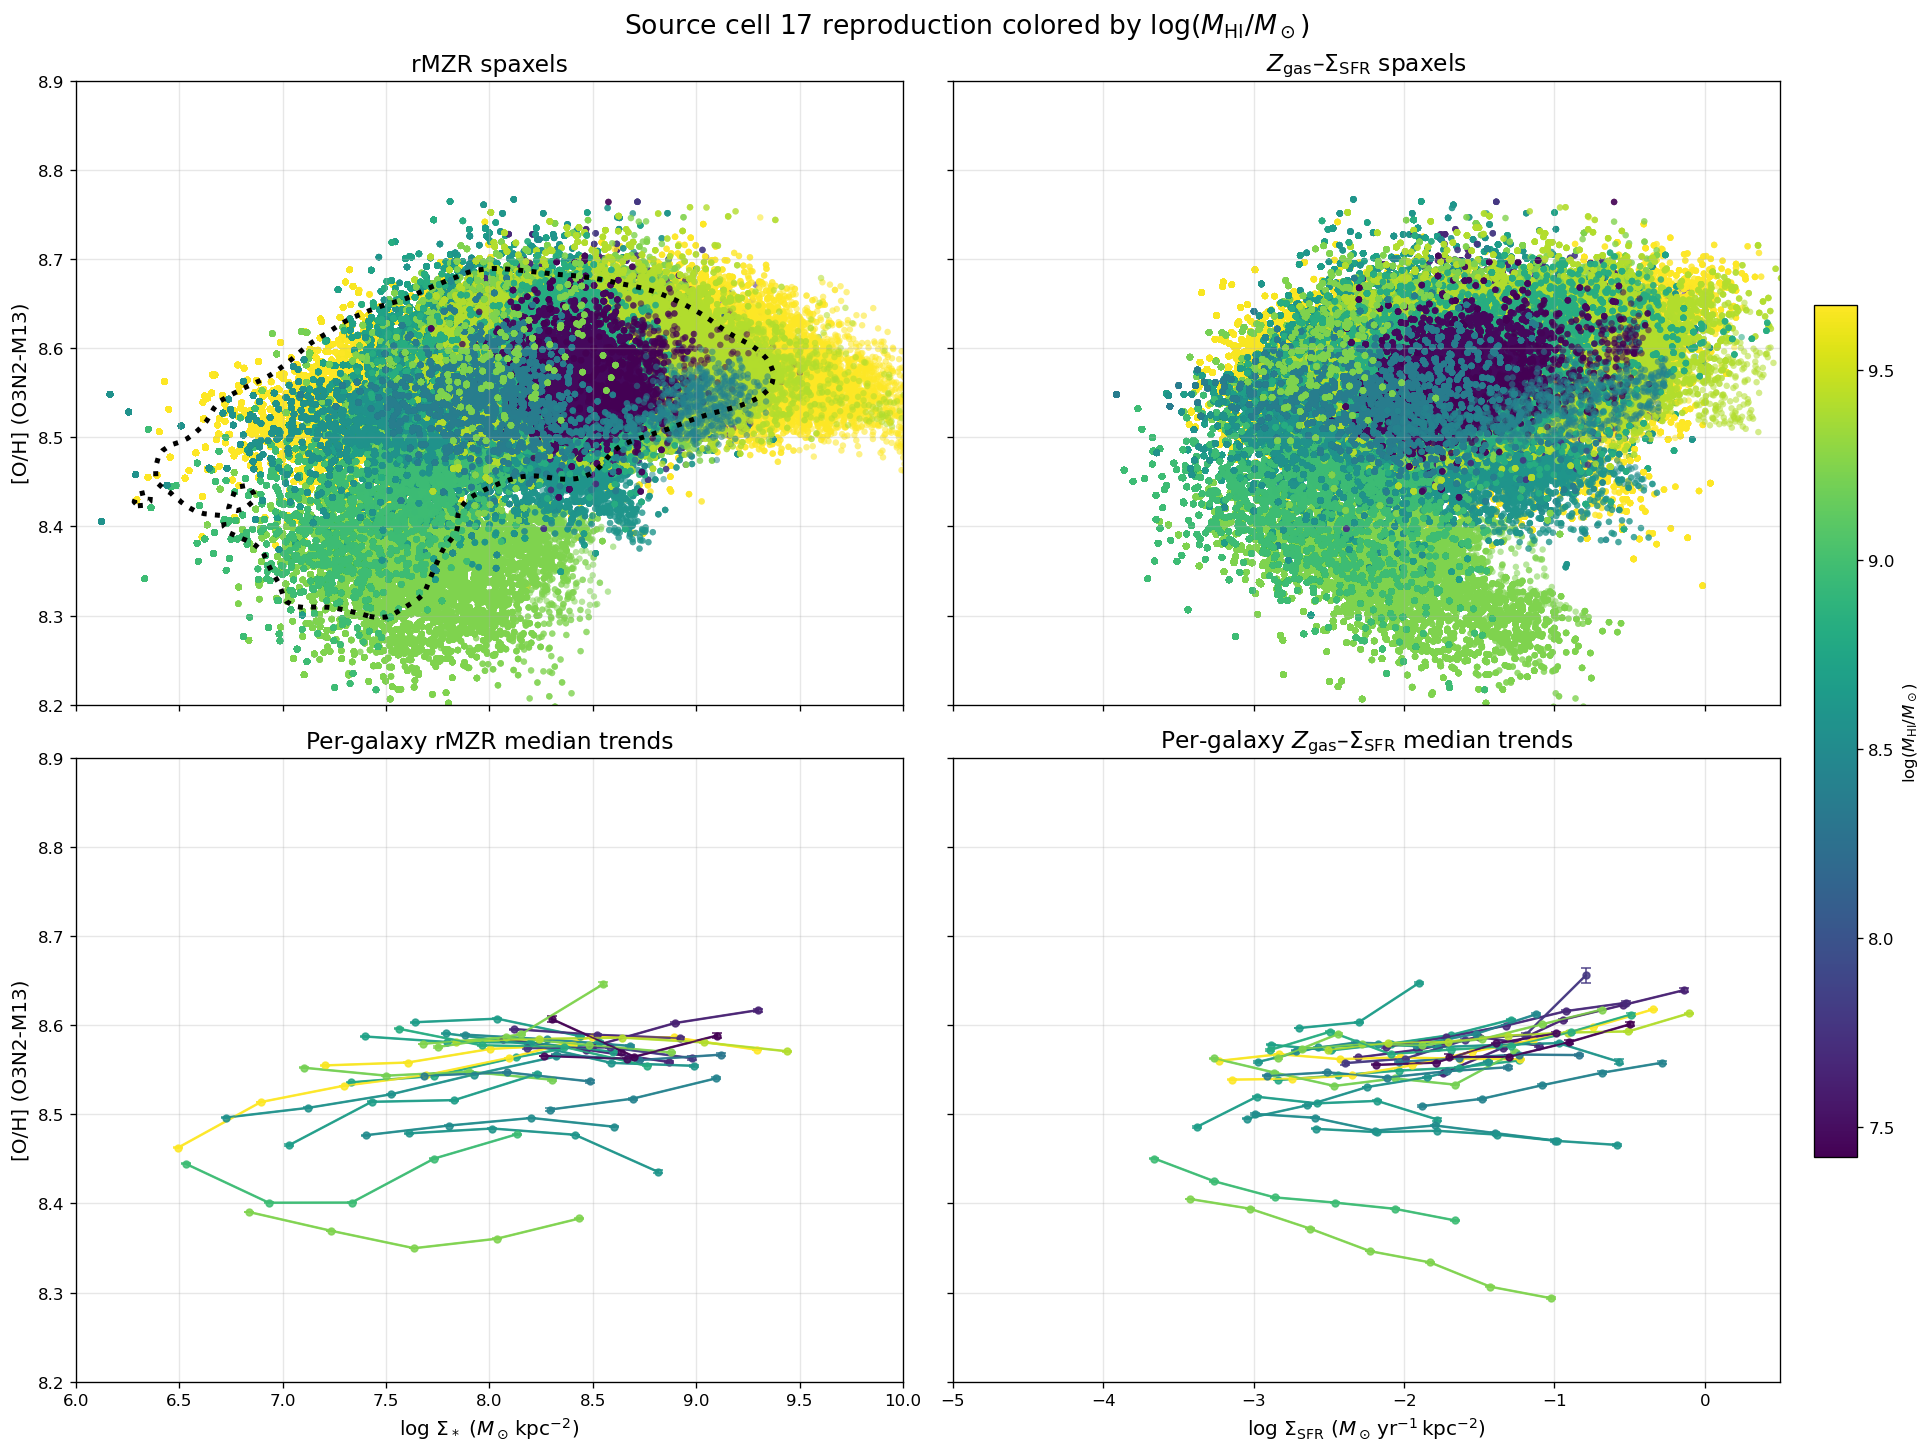

logMHI: plotted 28 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698


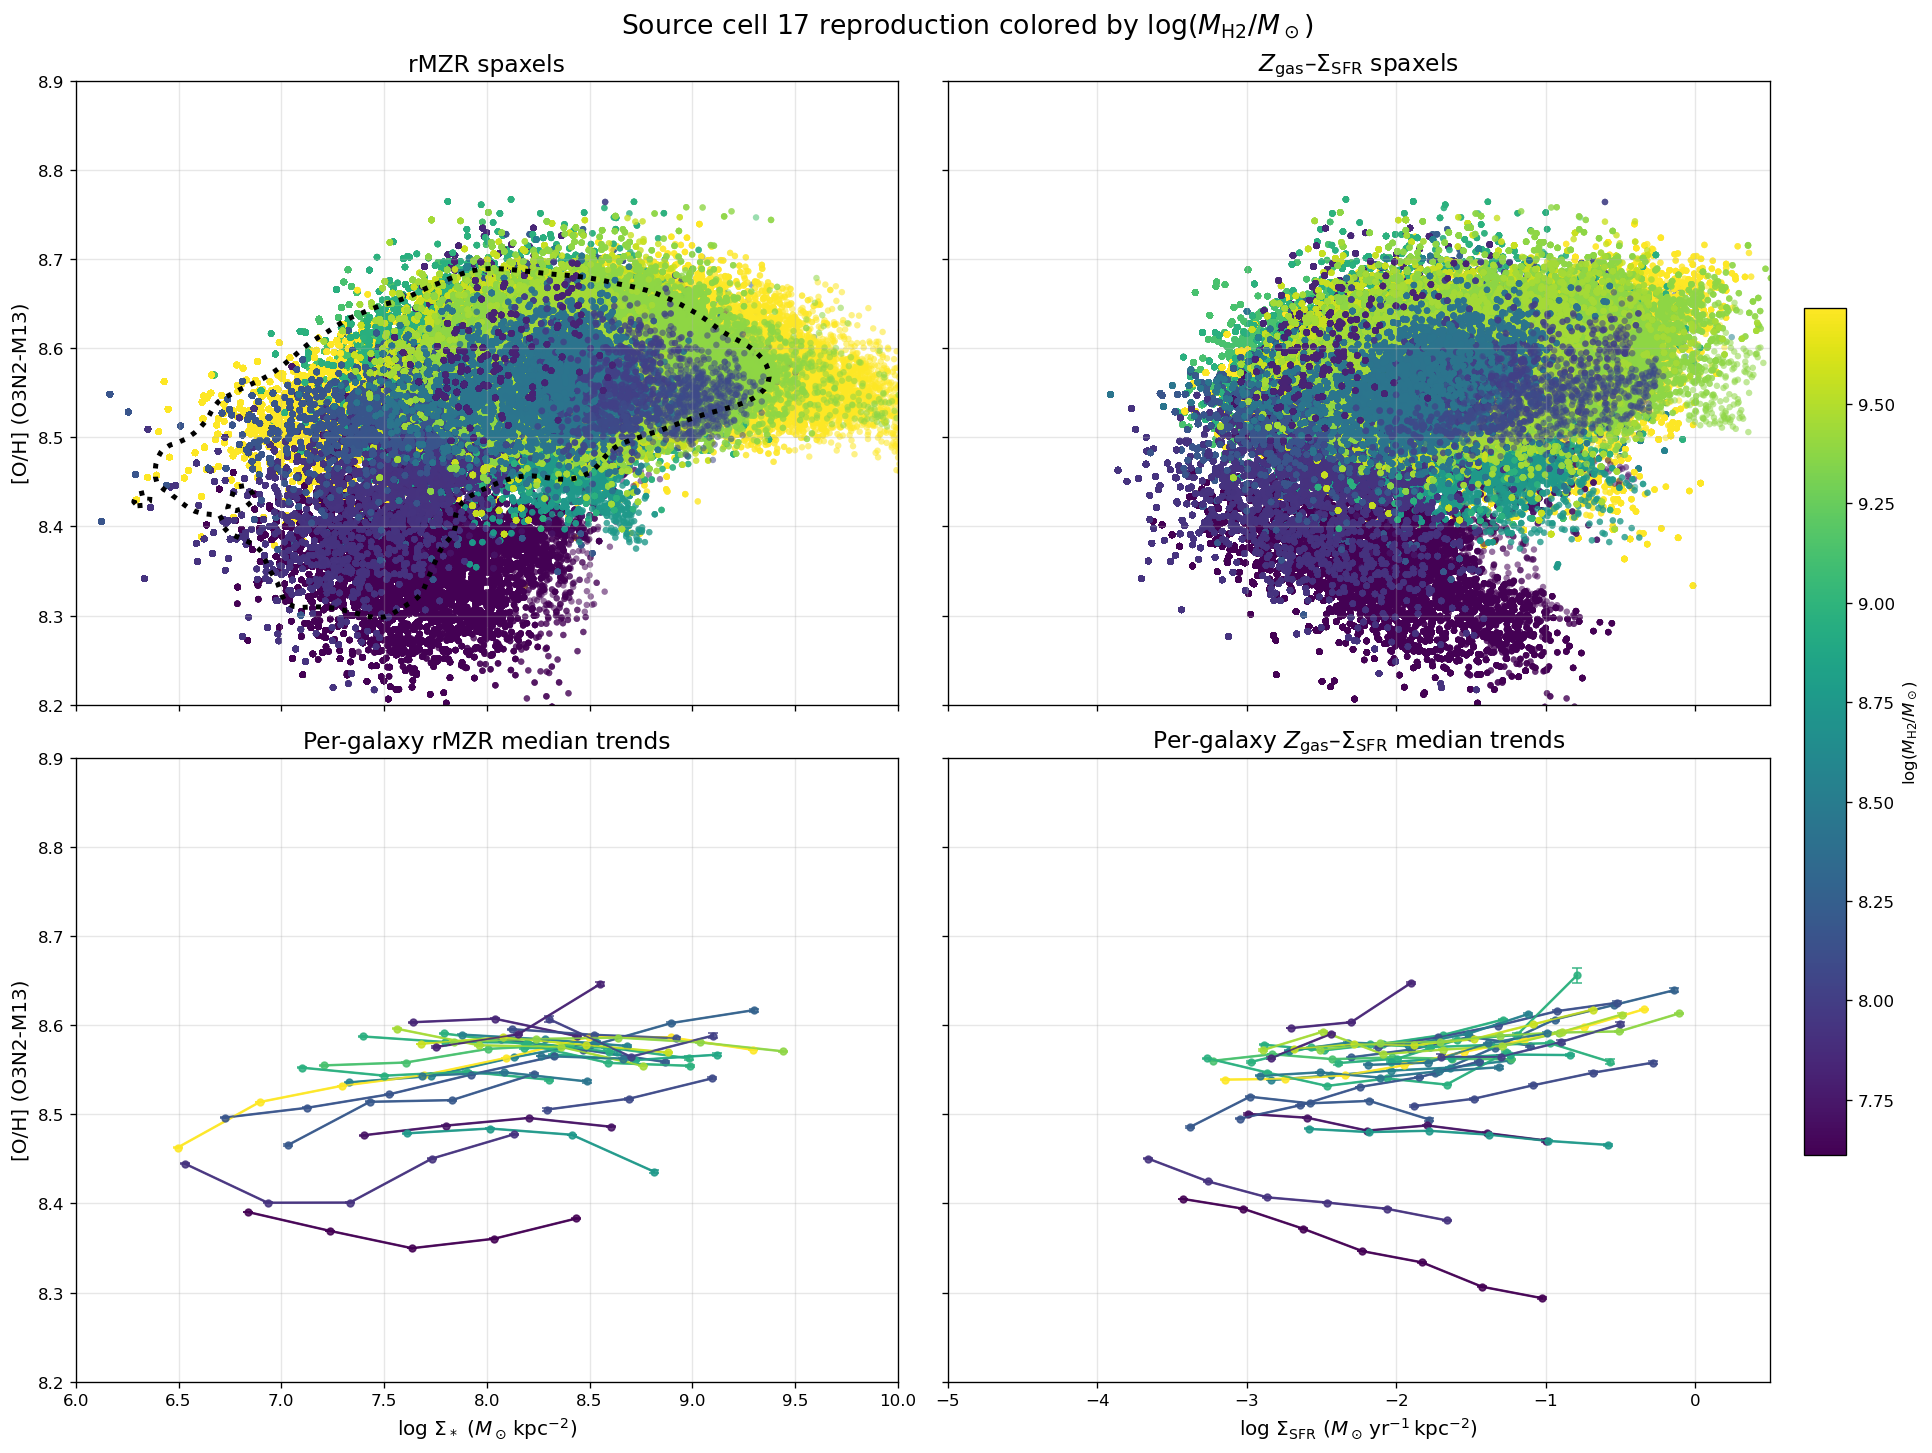

logMH2: plotted 28 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698


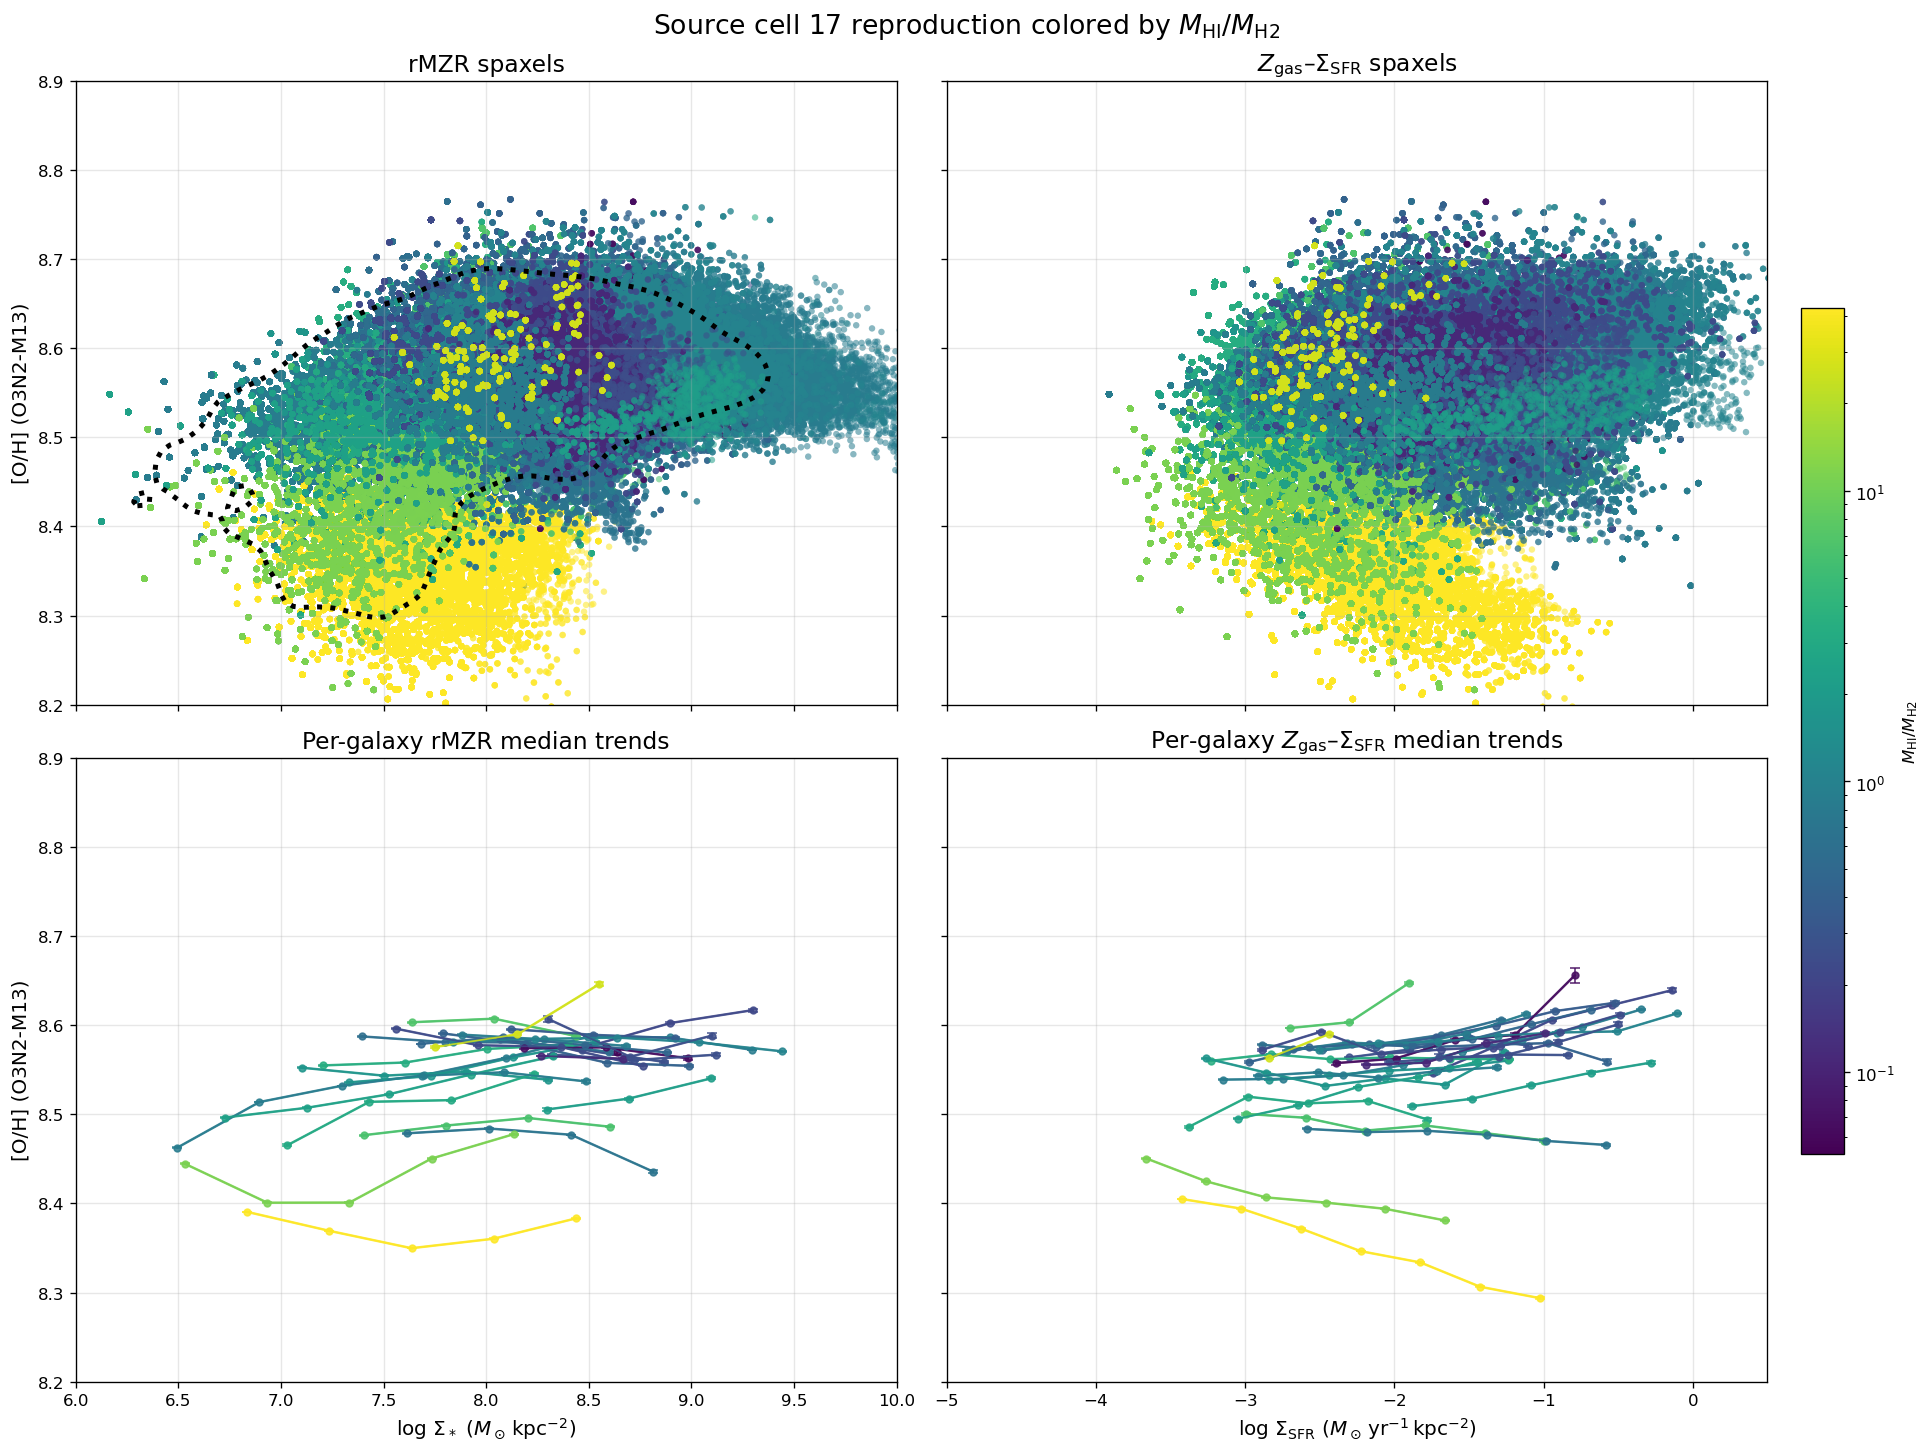

MHI_over_MH2: plotted 28 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698


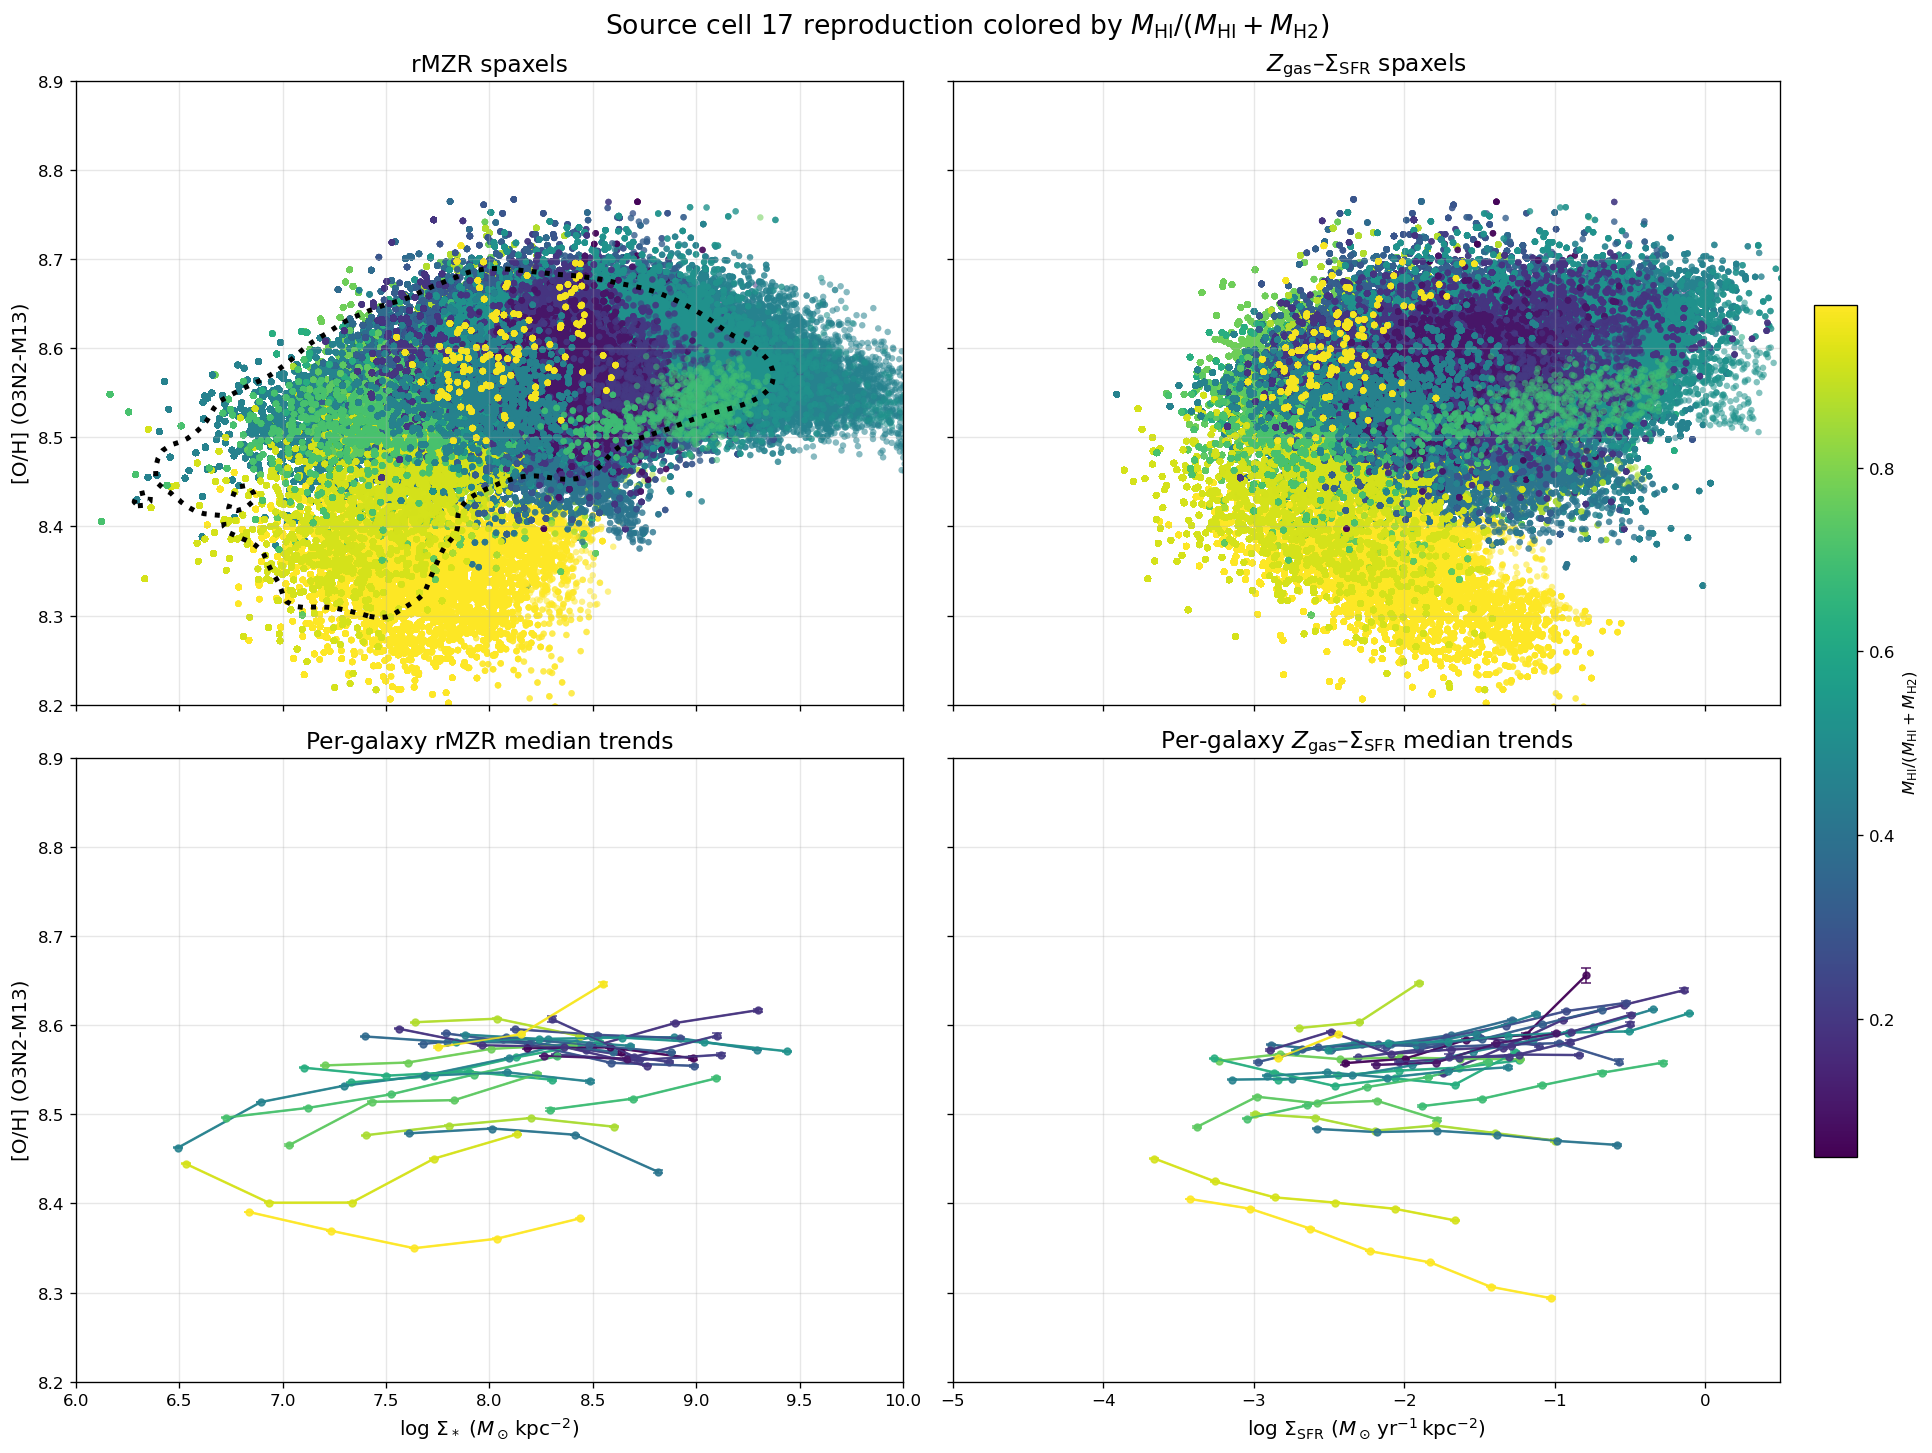

f_HI: plotted 28 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698


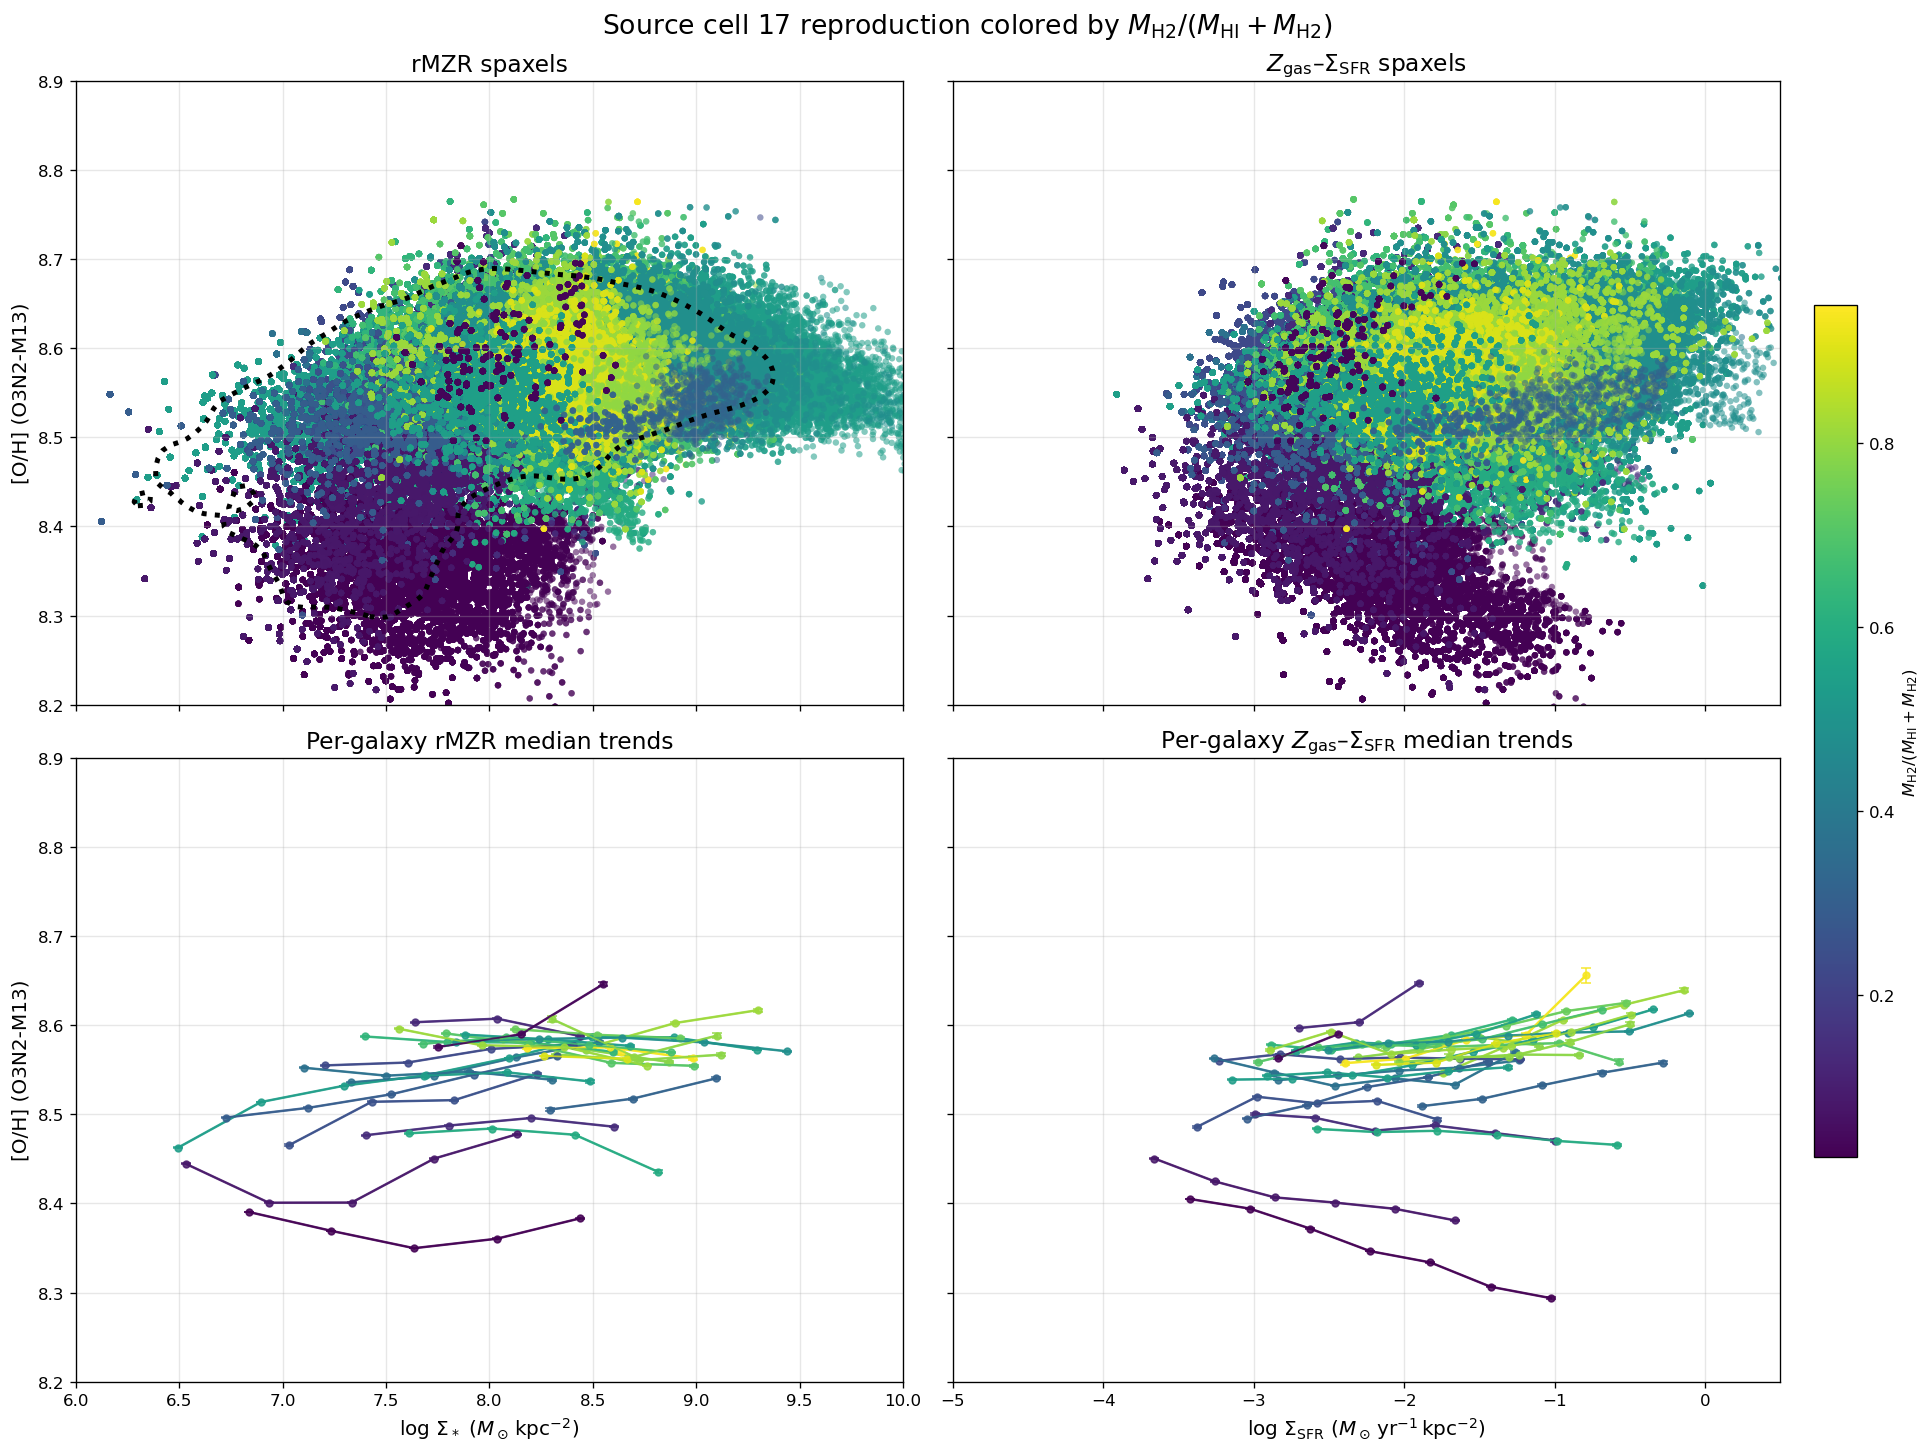

f_H2: plotted 28 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698


In [5]:
def collect_cell17_data():
    per_galaxy = {}
    candidates = [
        gal for gal in physics_ready_galaxies(require_ew=True)
        if gal not in EXCLUDED_GALAXIES and gal in GAS_PROPERTIES.index
    ]
    for galaxy in candidates:
        try:
            log_m, log_sfr, metallicity, indicator, ew_ha = load_hii_maps(
                galaxy, prefer_m14=False, include_ew=True
            )
        except Exception as exc:
            print(f"Skipping {galaxy}: {exc}")
            continue
        valid = (
            np.isfinite(log_m)
            & np.isfinite(log_sfr)
            & np.isfinite(metallicity)
            & np.isfinite(ew_ha)
        )
        if valid.sum() == 0:
            print(f"Skipping {galaxy}: no valid HII pixels")
            continue
        per_galaxy[galaxy] = {
            "log_m": log_m[valid],
            "log_sfr": log_sfr[valid],
            "metallicity": metallicity[valid],
            "indicator": indicator,
        }
        print(f"{galaxy}: {valid.sum()} valid HII pixels")
    return per_galaxy


CELL17_DATA = collect_cell17_data()


def plot_cell17_by_gas(metric_key, per_galaxy=CELL17_DATA):
    galaxies = sorted(per_galaxy)
    metric_values, cmap, norm, colorbar_label = metric_style(metric_key, galaxies)
    galaxies = [gal for gal in galaxies if gal in metric_values.index]
    if not galaxies:
        print(f"No galaxies can be plotted for {metric_key}")
        return

    all_log_m = np.concatenate([per_galaxy[gal]["log_m"] for gal in galaxies])
    all_log_sfr = np.concatenate([per_galaxy[gal]["log_sfr"] for gal in galaxies])
    all_metallicity = np.concatenate(
        [per_galaxy[gal]["metallicity"] for gal in galaxies]
    )

    fig, axes = plt.subplots(
        2, 2, figsize=(16, 12), sharex="col", sharey="all",
        constrained_layout=True
    )
    ax_rmzr_scatter, ax_zgas_scatter = axes[0]
    ax_rmzr_median, ax_zgas_median = axes[1]

    _, rmzr_contour = density_mask(
        all_log_m, all_metallicity, XRANGE_RMZR, COMMON_YLIM,
        return_contour=True
    )

    for galaxy in galaxies:
        data = per_galaxy[galaxy]
        color = cmap(norm(metric_values[galaxy]))
        log_m = data["log_m"]
        log_sfr = data["log_sfr"]
        metallicity = data["metallicity"]

        ax_rmzr_scatter.scatter(
            log_m, metallicity, color=color, s=15, alpha=0.55,
            edgecolors="none", rasterized=True
        )
        ax_zgas_scatter.scatter(
            log_sfr, metallicity, color=color, s=15, alpha=0.55,
            edgecolors="none", rasterized=True
        )

        rmzr_inside = density_mask(log_m, metallicity, XRANGE_RMZR, COMMON_YLIM)
        rmzr_stats = calculate_binned_stats(
            log_m[rmzr_inside], metallicity[rmzr_inside],
            bin_width=0.4, min_unique=20
        )
        plot_connected_medians(ax_rmzr_median, *rmzr_stats, color)

        zgas_inside = density_mask(log_sfr, metallicity, XRANGE_ZGAS, COMMON_YLIM)
        x = log_sfr[zgas_inside]
        y = metallicity[zgas_inside]
        if x.size > 1:
            x_std, y_std = np.nanstd(x), np.nanstd(y)
            clip = (
                (np.abs(x - np.nanmean(x)) < 3 * x_std)
                & (np.abs(y - np.nanmean(y)) < 3 * y_std)
            )
            zgas_stats = calculate_binned_stats(
                x[clip], y[clip], bin_width=0.4, min_unique=20
            )
            plot_connected_medians(ax_zgas_median, *zgas_stats, color)

    if rmzr_contour is not None:
        grid_x, grid_y, smooth, level = rmzr_contour
        ax_rmzr_scatter.contour(
            grid_x, grid_y, smooth, levels=[level],
            colors="black", linewidths=3, linestyles=":"
        )

    ax_rmzr_scatter.set_ylabel("[O/H] (O3N2-M13)", fontsize=12)
    ax_rmzr_median.set_xlabel(
        r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12
    )
    ax_rmzr_median.set_ylabel("[O/H] (O3N2-M13)", fontsize=12)
    ax_zgas_median.set_xlabel(
        r"$\log\,\Sigma_{\rm SFR} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$",
        fontsize=12,
    )

    for ax in axes[:, 0]:
        ax.set_xlim(*XRANGE_RMZR)
    for ax in axes[:, 1]:
        ax.set_xlim(*XRANGE_ZGAS)
    for ax in axes.ravel():
        ax.set_ylim(COMMON_YLIM)
        ax.grid(True, alpha=0.3)

    axes[0, 0].set_title("rMZR spaxels", fontsize=14)
    axes[0, 1].set_title(r"$Z_{\rm gas}$–$\Sigma_{\rm SFR}$ spaxels", fontsize=14)
    axes[1, 0].set_title("Per-galaxy rMZR median trends", fontsize=14)
    axes[1, 1].set_title(
        r"Per-galaxy $Z_{\rm gas}$–$\Sigma_{\rm SFR}$ median trends", fontsize=14
    )

    scalar_mappable = ScalarMappable(norm=norm, cmap=cmap)
    scalar_mappable.set_array([])
    fig.colorbar(
        scalar_mappable, ax=axes, location="right", fraction=0.025,
        pad=0.02, label=colorbar_label
    )
    fig.suptitle(
        f"Source cell 17 reproduction colored by {colorbar_label}",
        fontsize=16,
    )
    plt.show()
    print(f"{metric_key}: plotted {len(galaxies)} galaxies: {', '.join(galaxies)}")


for metric_key in GAS_METRICS:
    plot_cell17_by_gas(metric_key)


## Reproduction of source cell 22: Spearman $\rho$ versus EW(Hα)

The source cell's per-galaxy EW(Hα)-binned Spearman calculation is retained:
offsets are measured within six EW(Hα) bins, independently clipped at 3σ using
unique values, and accepted only when at least three median-trend points exist.
The pooled trend is black. Per-galaxy lines are colored continuously by each
global gas property.

IC3392: 5 valid Spearman bins (O3N2-M13)
NGC4064: 5 valid Spearman bins (O3N2-M13)
NGC4189: 5 valid Spearman bins (O3N2-M13)
NGC4192: 6 valid Spearman bins (O3N2-M13)
NGC4254: 6 valid Spearman bins (O3N2-M13)
NGC4293: 0 valid Spearman bins (O3N2-M13)
NGC4294: 5 valid Spearman bins (O3N2-M13)
NGC4298: 6 valid Spearman bins (O3N2-M13)
NGC4302: 0 valid Spearman bins (O3N2-M13)
NGC4330: 4 valid Spearman bins (O3N2-M13)
NGC4351: 4 valid Spearman bins (O3N2-M13)
NGC4388: 4 valid Spearman bins (O3N2-M13)
NGC4394: 0 valid Spearman bins (O3N2-M13)
NGC4396: 4 valid Spearman bins (O3N2-M13)
NGC4402: 6 valid Spearman bins (O3N2-M13)
NGC4405: 6 valid Spearman bins (O3N2-M13)
NGC4419: 4 valid Spearman bins (O3N2-M13)
NGC4450: 3 valid Spearman bins (O3N2-M13)
NGC4457: 3 valid Spearman bins (O3N2-M13)
NGC4501: 6 valid Spearman bins (O3N2-M13)
NGC4522: 3 valid Spearman bins (O3N2-M13)
NGC4567_8: 6 valid Spearman bins (O3N2-M13)
NGC4569: 4 valid Spearman bins (O3N2-M13)
NGC4580: 6 valid Spearman bins (O

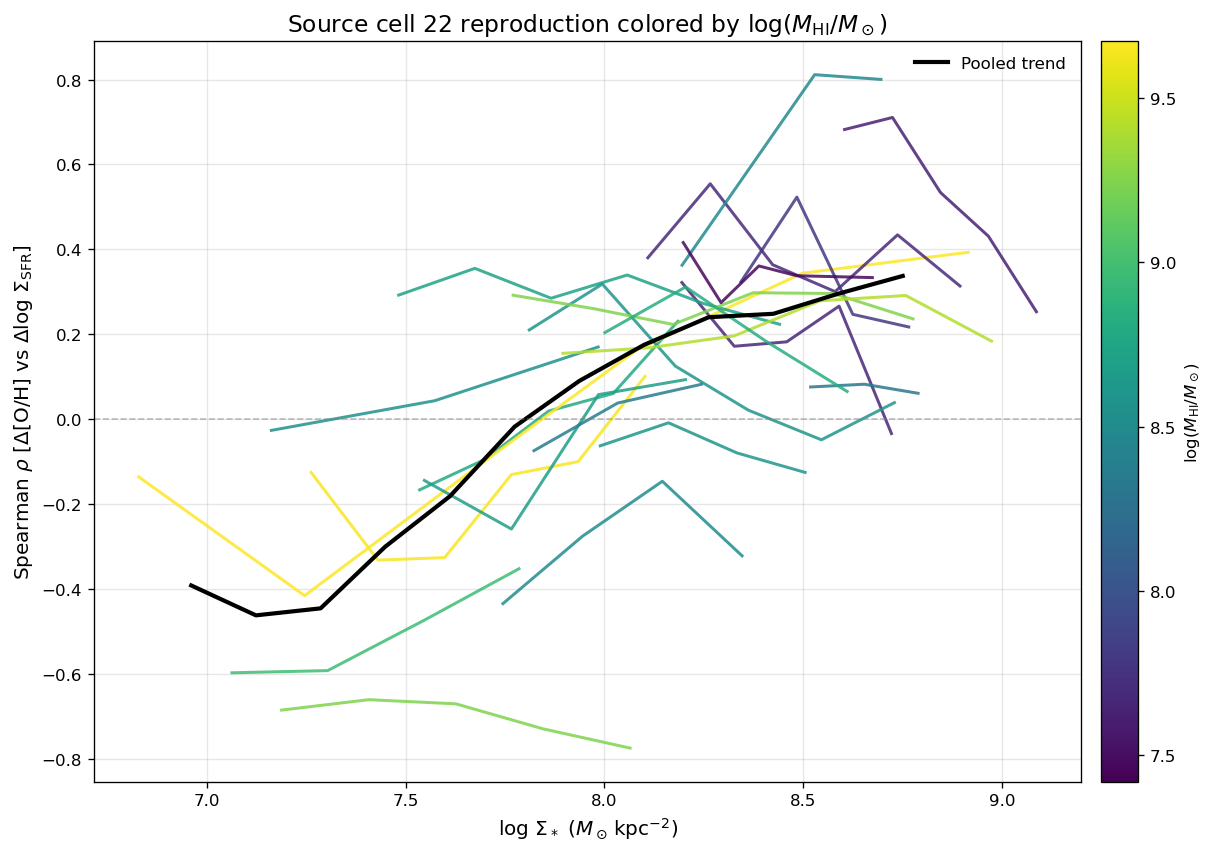

logMHI: plotted 22 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4294, NGC4298, NGC4330, NGC4351, NGC4388, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4607


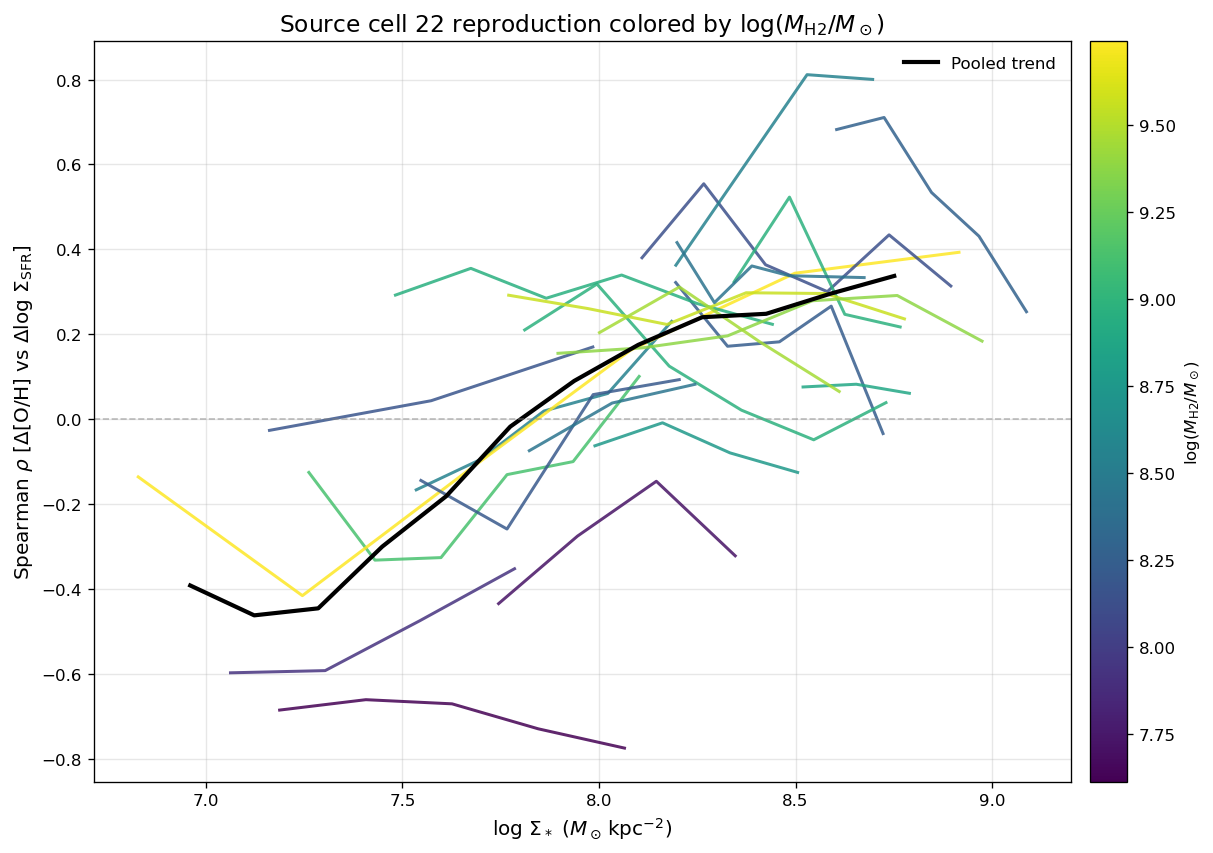

logMH2: plotted 22 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4294, NGC4298, NGC4330, NGC4351, NGC4388, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4607


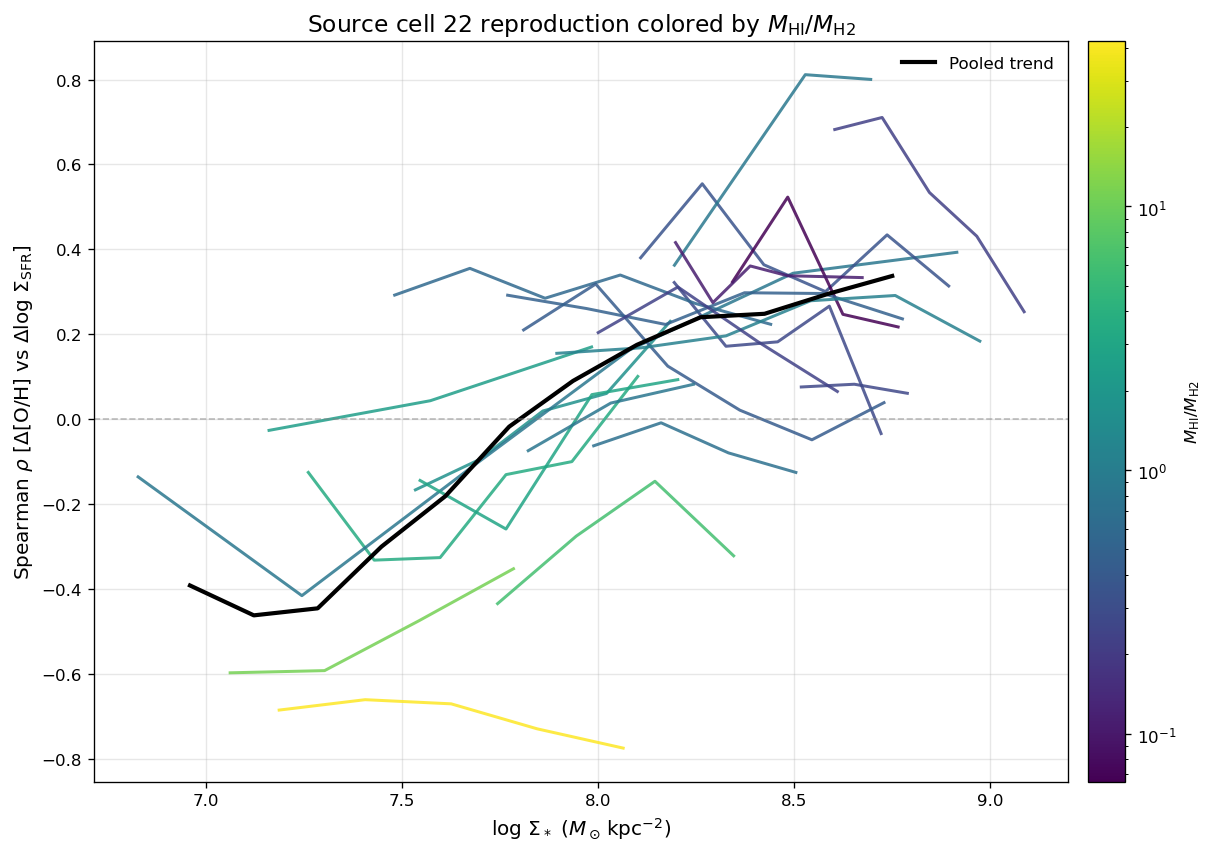

MHI_over_MH2: plotted 22 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4294, NGC4298, NGC4330, NGC4351, NGC4388, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4607


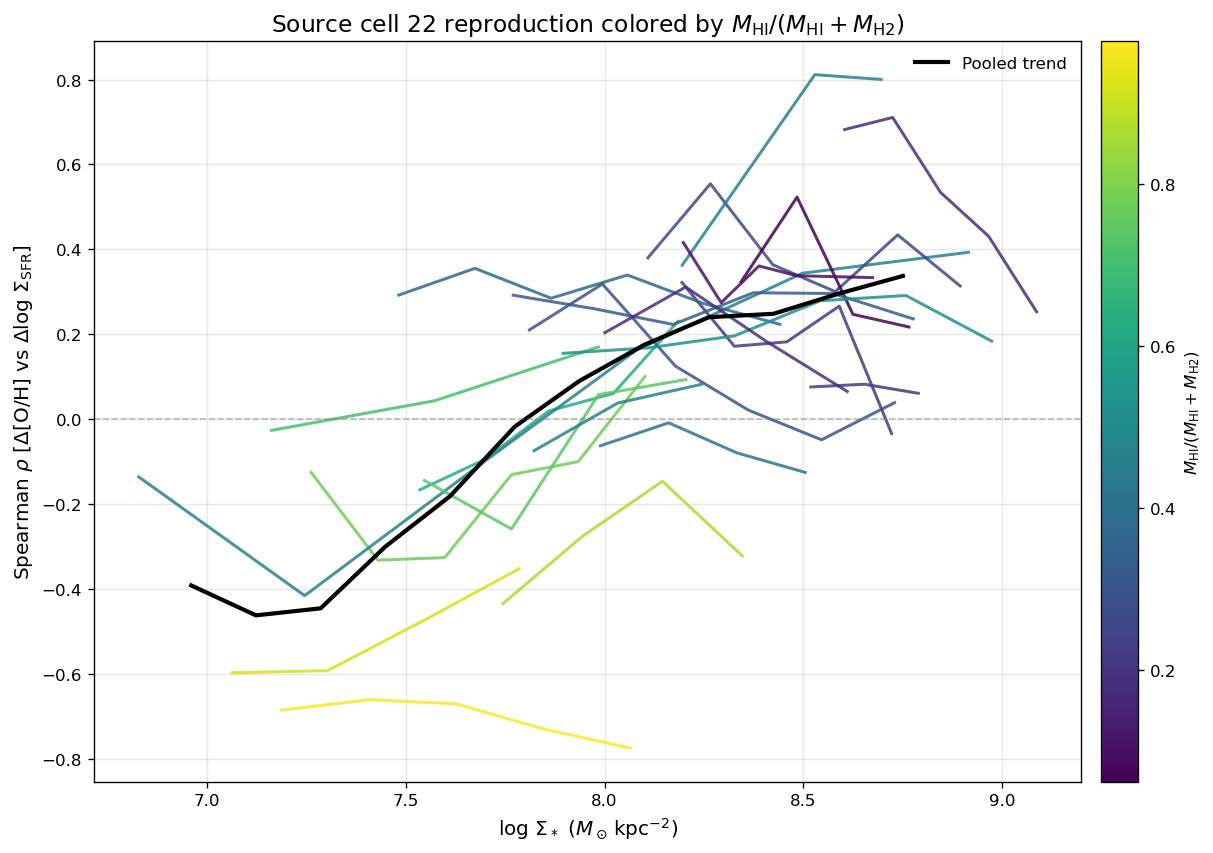

f_HI: plotted 22 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4294, NGC4298, NGC4330, NGC4351, NGC4388, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4607


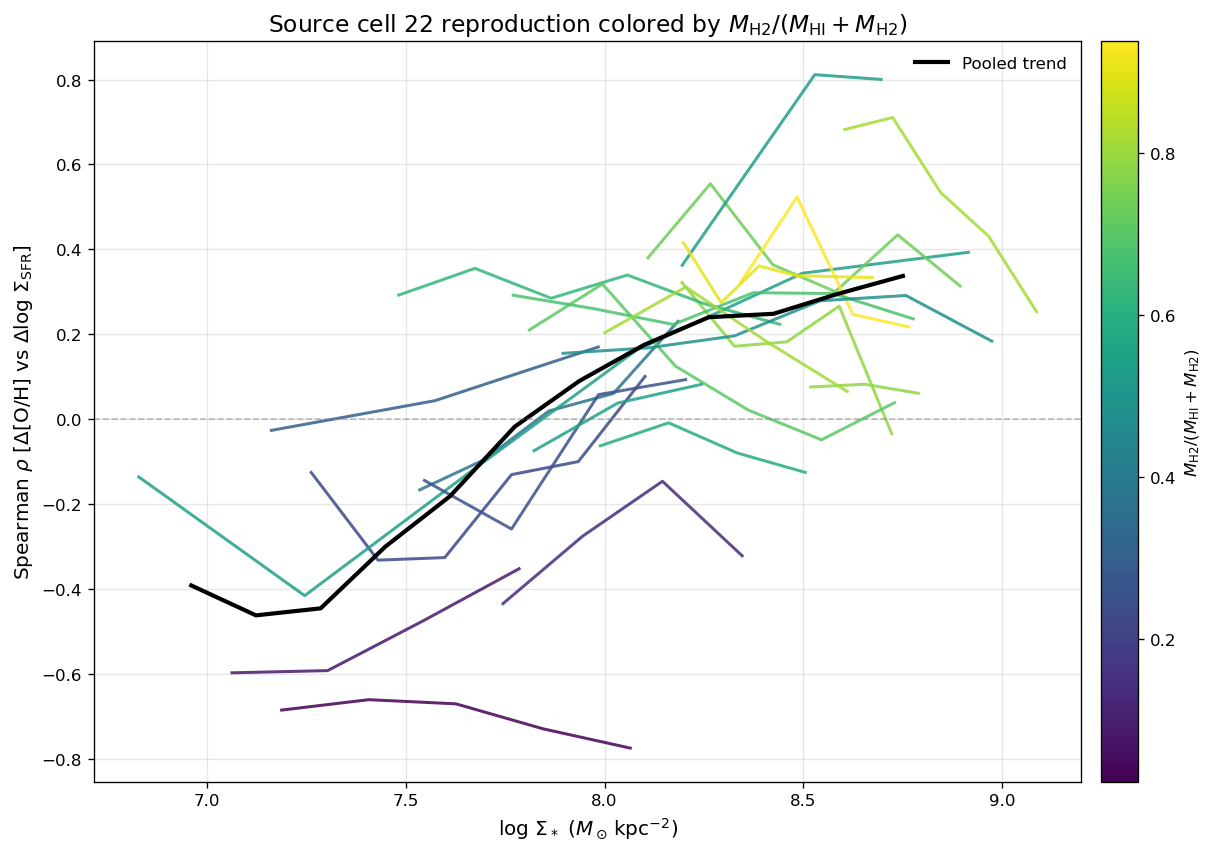

f_H2: plotted 22 galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4294, NGC4298, NGC4330, NGC4351, NGC4388, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4607


In [6]:
def rho_curve_from_binned_offsets(primary, sfr_offset, oh_offset, *, edges):
    centers_out = []
    rho_out = []
    for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if i == len(edges) - 2:
            in_bin = (primary >= left) & (primary <= right)
        else:
            in_bin = (primary >= left) & (primary < right)
        if in_bin.sum() <= 2:
            continue

        x = sfr_offset[in_bin]
        y = oh_offset[in_bin]
        clip = sigma_clip_unique(x, y)
        trend = calculate_binned_stats(
            x[clip], y[clip], bin_width=0.2, min_unique=20
        )
        if trend[0].size < 3 or clip.sum() <= 2:
            continue
        rho, _ = stats.spearmanr(x[clip], y[clip])
        if np.isfinite(rho):
            centers_out.append(0.5 * (left + right))
            rho_out.append(rho)
    return np.asarray(centers_out), np.asarray(rho_out)


def collect_cell22_curves():
    per_galaxy = {}
    pooled_sigma_m = []
    pooled_sfr_offset = []
    pooled_oh_offset = []

    candidates = [
        gal for gal in physics_ready_galaxies(require_ew=True)
        if gal not in EXCLUDED_GALAXIES and gal in GAS_PROPERTIES.index
    ]

    for galaxy in candidates:
        try:
            log_m, log_sfr, metallicity, indicator, ew_ha = load_hii_maps(
                galaxy, prefer_m14=True, include_ew=True
            )
        except Exception as exc:
            print(f"Skipping {galaxy}: {exc}")
            continue

        valid = (
            np.isfinite(log_m)
            & np.isfinite(log_sfr)
            & np.isfinite(metallicity)
            & np.isfinite(ew_ha)
        )
        if valid.sum() == 0:
            continue

        sigma_m = log_m[valid]
        sfr = log_sfr[valid]
        oh = metallicity[valid]
        sigma_m_min, sigma_m_max = np.nanpercentile(sigma_m, [2.5, 97.5])
        if not np.isfinite(sigma_m_min) or not np.isfinite(sigma_m_max):
            print(f"Skipping {galaxy}: invalid stellar mass surface-density range")
            continue
        edges = np.linspace(sigma_m_min, sigma_m_max, 7)

        galaxy_primary = []
        galaxy_sfr_offset = []
        galaxy_oh_offset = []
        for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
            if i == len(edges) - 2:
                in_bin = (sigma_m >= left) & (sigma_m <= right)
            else:
                in_bin = (sigma_m >= left) & (sigma_m < right)
            if in_bin.sum() == 0:
                continue
            sfr_offset = sfr[in_bin] - np.mean(sfr[in_bin])
            oh_offset = oh[in_bin] - np.mean(oh[in_bin])
            finite = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            if finite.sum() == 0:
                continue
            galaxy_primary.append(sigma_m[in_bin][finite])
            galaxy_sfr_offset.append(sfr_offset[finite])
            galaxy_oh_offset.append(oh_offset[finite])

        if not galaxy_primary:
            continue

        primary = np.concatenate(galaxy_primary)
        sfr_offset = np.concatenate(galaxy_sfr_offset)
        oh_offset = np.concatenate(galaxy_oh_offset)
        centers, rho = rho_curve_from_binned_offsets(
            primary, sfr_offset, oh_offset, edges=edges
        )
        if rho.size:
            per_galaxy[galaxy] = {
                "sigma_m": centers,
                "rho": rho,
                "indicator": indicator,
            }
        pooled_sigma_m.append(primary)
        pooled_sfr_offset.append(sfr_offset)
        pooled_oh_offset.append(oh_offset)
        print(f"{galaxy}: {rho.size} valid Spearman bins ({indicator})")

    pooled_curve = (np.array([]), np.array([]))
    if pooled_sigma_m:
        primary = np.concatenate(pooled_sigma_m)
        sfr_offset = np.concatenate(pooled_sfr_offset)
        oh_offset = np.concatenate(pooled_oh_offset)
        sigma_m_min, sigma_m_max = np.nanpercentile(primary, [2.5, 97.5])
        pooled_edges = np.linspace(sigma_m_min, sigma_m_max, 13)
        pooled_curve = rho_curve_from_binned_offsets(
            primary, sfr_offset, oh_offset, edges=pooled_edges
        )
    return per_galaxy, pooled_curve


CELL22_CURVES, CELL22_POOLED_CURVE = collect_cell22_curves()


def plot_cell22_by_gas(
    metric_key, per_galaxy=CELL22_CURVES, pooled_curve=CELL22_POOLED_CURVE
):
    galaxies = sorted(per_galaxy)
    metric_values, cmap, norm, colorbar_label = metric_style(metric_key, galaxies)
    galaxies = [gal for gal in galaxies if gal in metric_values.index]

    fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
    plotted = []
    for galaxy in galaxies:
        sigma_m = per_galaxy[galaxy]["sigma_m"]
        rho = per_galaxy[galaxy]["rho"]
        if sigma_m.size <= 2:
            continue
        order = np.argsort(sigma_m)
        color = cmap(norm(metric_values[galaxy]))
        ax.plot(sigma_m[order], rho[order], color=color, linewidth=1.8, alpha=0.85)
        plotted.append(galaxy)

    pooled_sigma_m, pooled_rho = pooled_curve
    if pooled_rho.size > 2:
        order = np.argsort(pooled_sigma_m)
        ax.plot(
            pooled_sigma_m[order], pooled_rho[order],
            color="black", linewidth=2.5, label="Pooled trend"
        )
        ax.legend(frameon=False, loc="best")

    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.5)
    ax.set_xlabel(
        r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12
    )
    ax.set_ylabel(
        r"Spearman $\rho$ [$\Delta$[O/H] vs "
        r"$\Delta\log\,\Sigma_{\mathrm{SFR}}$]",
        fontsize=12,
    )
    ax.set_title(
        f"Source cell 22 reproduction colored by {colorbar_label}",
        fontsize=14,
    )
    ax.grid(True, alpha=0.3)

    scalar_mappable = ScalarMappable(norm=norm, cmap=cmap)
    scalar_mappable.set_array([])
    fig.colorbar(scalar_mappable, ax=ax, pad=0.02, label=colorbar_label)
    plt.show()
    print(f"{metric_key}: plotted {len(plotted)} galaxies: {', '.join(plotted)}")


for metric_key in GAS_METRICS:
    plot_cell22_by_gas(metric_key)
